In [14]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

## 1. Extract

In [13]:
# File path configuration
PATH_REVIEWS = "../../data/reviews.csv"

# Load the dataset
df_rev = pd.read_csv(PATH_REVIEWS)
print(f"Total records loaded: {len(df_rev)}")
df_rev.head(3)

Total records loaded: 487221


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,96033,8152056,2013-10-18,366364,Vera,My stay at the apartment of Adriana and Rafa w...
1,96033,8689156,2013-11-12,4862098,Sarah,The flat was perfect for our holiday in Malaga...
2,96033,11862773,2014-04-17,2236416,Galina,El piso esta muy lindo y comido :) No había in...


## 2. Transform: Cleaning and Formatting

In [15]:
# Create working copy
df_trans = df_rev.copy()

# 1. Transform date to datetime format
df_trans['date'] = pd.to_datetime(df_trans['date'])

# 2. Key Observation: Drop rows with null comments (20 missing values)
df_trans = df_trans.dropna(subset=['comments'])

# 3. Remove row with null ID (Reviewer name)
# Based on your updated notes to remove null IDs
df_trans = df_trans.dropna(subset=['reviewer_id'])

# 4. We add comment length
df_trans['comments_len'] = df_trans['comments'].astype(str).apply(len)

# 5. Drop 'reviewer_name'
if 'reviewer_name' in df_trans.columns:
    df_trans = df_trans.drop(columns=['reviewer_name'])

print(f"Records after transformation: {len(df_trans)}")

Records after transformation: 487201


## 3. Validation

In [16]:
# Ensure listing_id is present and not null
null_listings = df_trans['listing_id'].isnull().sum()

if null_listings == 0:
    print("Validation Successful: All listing_ids are present and valid.")
else:
    print(f"Validation Warning: Found {null_listings} null listing_ids.")

Validation Successful: All listing_ids are present and valid.


## 4. EDA: Exploratory Data Anlysis


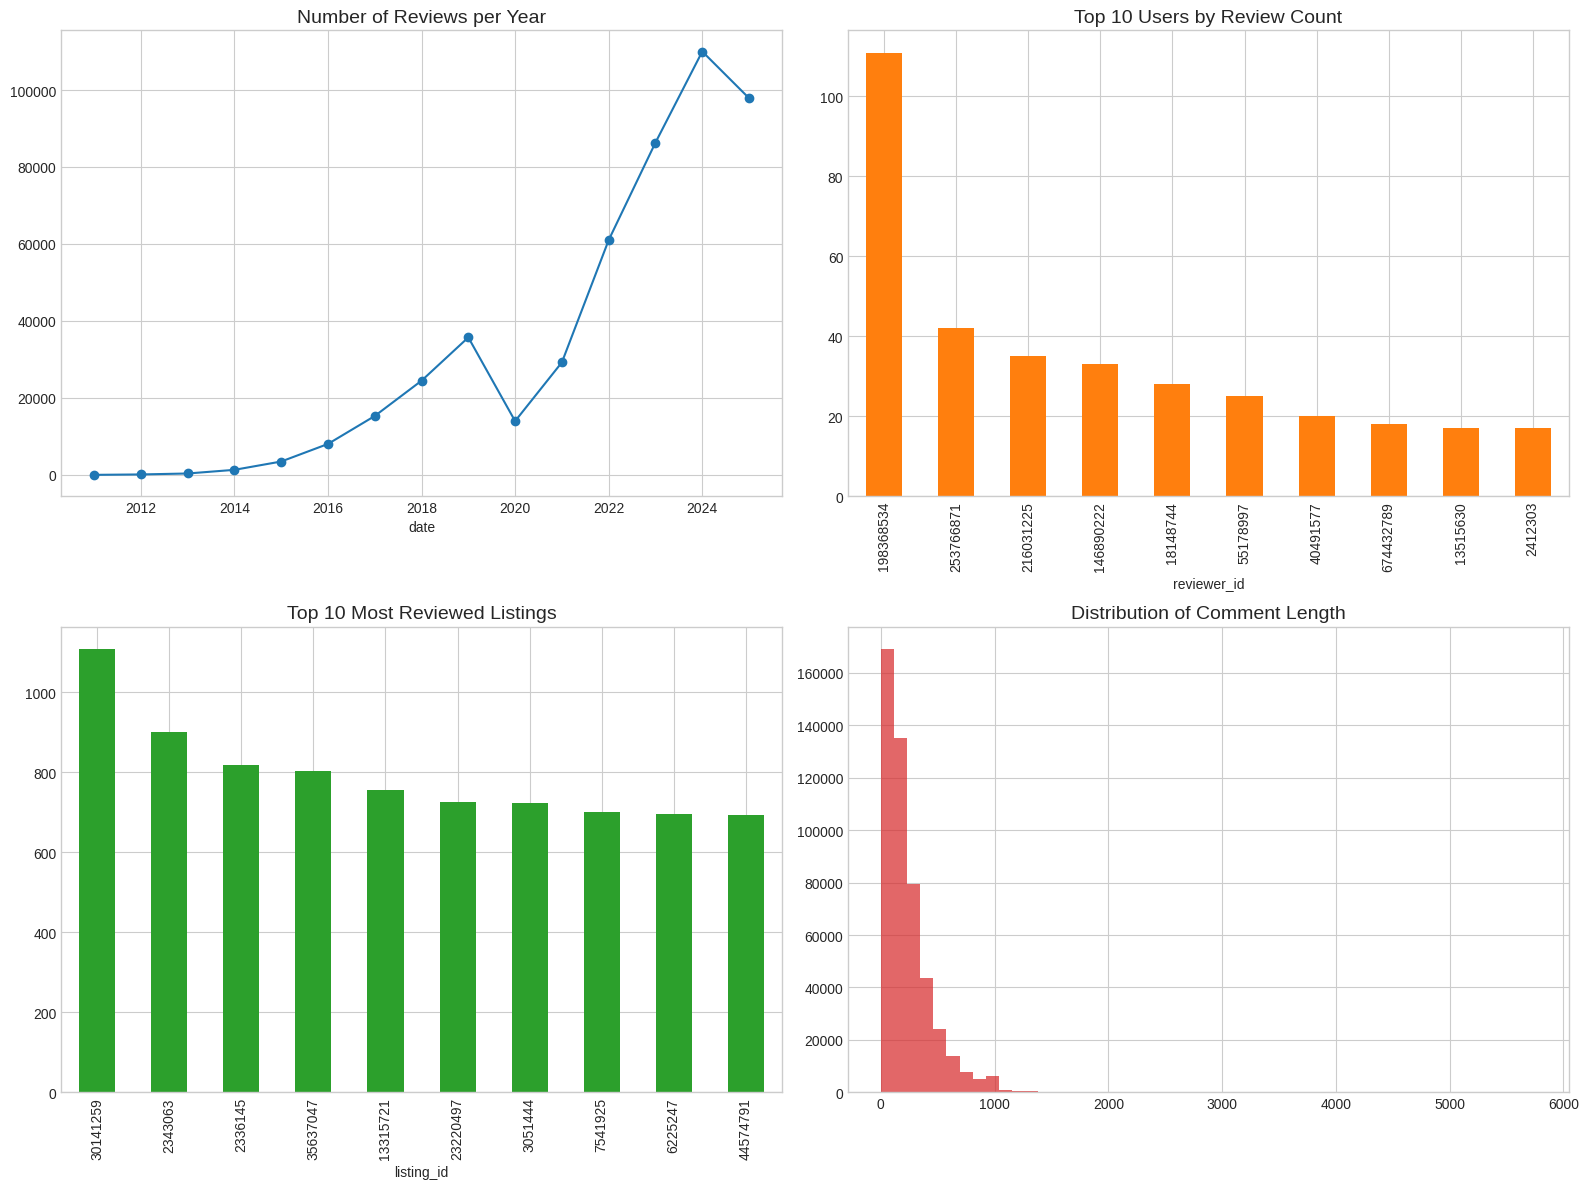

In [17]:
# Setup plot style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Number of reviews per year
df_trans.groupby(df_trans['date'].dt.year).size().plot(kind='line', ax=axs[0,0], marker='o', color='#1f77b4')
axs[0,0].set_title('Number of Reviews per Year', fontsize=14)

# 2. Number of reviews per user
df_trans['reviewer_id'].value_counts().head(10).plot(kind='bar', ax=axs[0,1], color='#ff7f0e')
axs[0,1].set_title('Top 10 Users by Review Count', fontsize=14)

# 3. Number of reviews per listing
df_trans['listing_id'].value_counts().head(10).plot(kind='bar', ax=axs[1,0], color='#2ca02c')
axs[1,0].set_title('Top 10 Most Reviewed Listings', fontsize=14)

# 4. Comment length distribution
df_trans['comments_len'].hist(bins=50, ax=axs[1,1], color='#d62728', alpha=0.7)
axs[1,1].set_title('Distribution of Comment Length', fontsize=14)

plt.tight_layout()
plt.show()

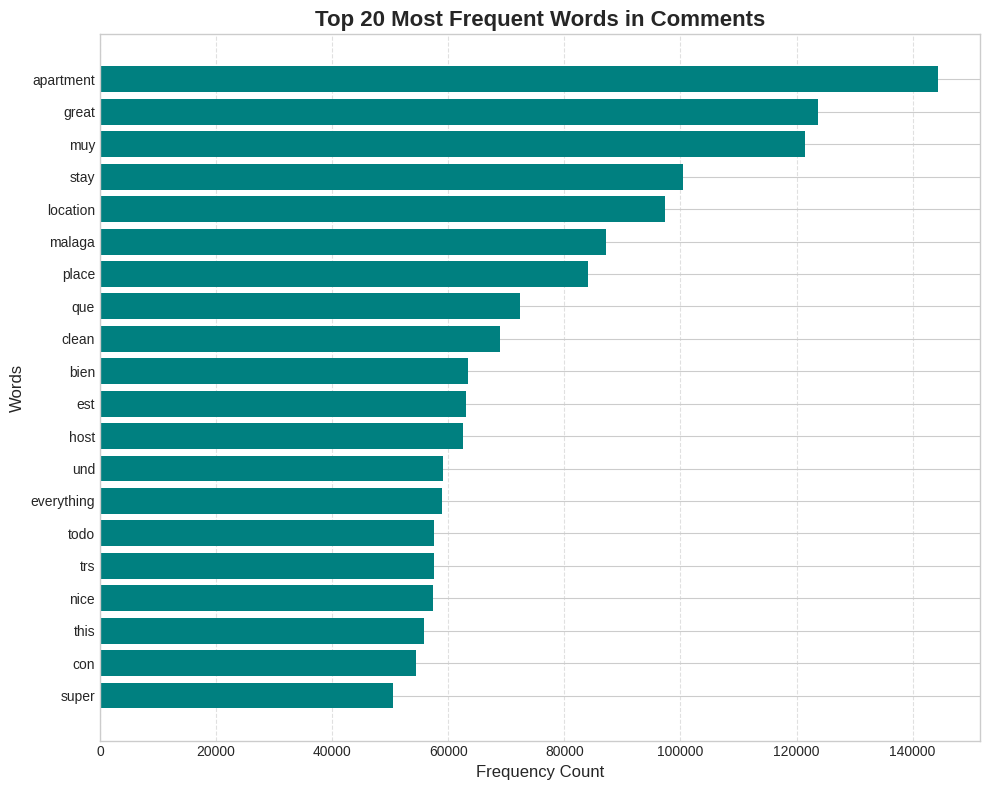

In [20]:
# ---------- Most Frequent Words in Comments ----------
from collections import Counter
import re

# 1. Define a list of common English stopwords to filter out noise
# These are words that don't add much meaning to the analysis
ENG_STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'if', 'because', 'as', 'until', 'while',
    'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through',
    'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in',
    'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few',
    'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same',
    'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now',
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'he', 'him', 'his', 'she', 'her', 'it', 'its', 'they', 'them', 'their', 'was', 'were', 
    'be', 'is', 'are', 'am', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'would'
}

# 2. Join all comments into a single string and clean it
# We convert to lowercase and remove non-alphabetical characters
all_text = " ".join(df_trans['comments'].astype(str).str.lower())
cleaned_text = re.sub(r'[^a-z\s]', '', all_text)

# 3. Tokenize and filter the words
words = cleaned_text.split()
meaningful_words = [w for w in words if w not in ENG_STOPWORDS and len(w) > 2]

# 4. Count frequencies and get the top 20
word_counts = Counter(meaningful_words)
df_top_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

# 5. Create the horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(df_top_words['Word'], df_top_words['Count'], color='teal')

# Add titles and labels in English
plt.title('Top 20 Most Frequent Words in Comments', fontsize=16, fontweight='bold')
plt.xlabel('Frequency Count', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.gca().invert_yaxis()  # Display the most frequent word at the top

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()